In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

# ── 1. Configuration ──────────────────────────────────────────────
TICKERS  = ['AAPL', 'JPM', 'MSFT', 'GS', 'XOM']   # 5 stocks
WEIGHTS  = np.array([0.25, 0.25, 0.20, 0.15, 0.15]) # must sum to 1
START    = '2018-01-01'
END      = '2024-01-01'
CONF     = 0.95        # 95% confidence level
HORIZON  = 1           # 1-day VaR


In [4]:
# ── 2. Download prices ────────────────────────────────────────────
print("Downloading data...")
raw   = yf.download(TICKERS, start=START, end=END)['Close']
raw   = raw.dropna()


[*********************100%***********************]  5 of 5 completed


In [5]:
# ── 3. Daily log returns ──────────────────────────────────────────
returns = np.log(raw / raw.shift(1)).dropna()



In [6]:
# ── 4. Weighted portfolio return (single series) ──────────────────
port_returns = returns.dot(WEIGHTS)
print(f"Data loaded: {len(port_returns)} trading days")
print(f"Date range : {port_returns.index[0].date()} → {port_returns.index[-1].date()}")
print(f"Mean daily return : {port_returns.mean():.4f}")
print(f"Daily volatility  : {port_returns.std():.4f}")


Data loaded: 1508 trading days
Date range : 2018-01-03 → 2023-12-29
Mean daily return : 0.0006
Daily volatility  : 0.0158


In [7]:
# METHOD 1 — HISTORICAL SIMULATION
# This method makes no assumptions about the distribution of returns.
# Idea: take the last 250 days of actual returns, sort them,
# and read off the 5th percentile. No assumptions about distribution.

WINDOW = 250  # 1 trading year

def historical_var(returns_series, window, confidence):
    """
    Rolls a window across the return series.
    At each day, sorts the past 'window' returns and takes
    the (1-confidence) percentile as the VaR estimate.
    Returns a Series aligned to the original index.
    """
    var_series = pd.Series(index=returns_series.index, dtype=float)

    for i in range(window, len(returns_series)):
        window_returns = returns_series.iloc[i - window:i]
        var_series.iloc[i] = np.percentile(window_returns, (1 - confidence) * 100)

    return var_series.dropna()

hs_var = historical_var(port_returns, WINDOW, CONF)

print("\n── Historical Simulation VaR ──")
print(f"Average VaR (95%): {hs_var.mean():.4f}")
print(f"Worst VaR day    : {hs_var.min():.4f}")


── Historical Simulation VaR ──
Average VaR (95%): -0.0245
Worst VaR day    : -0.0400


In [8]:
# ══════════════════════════════════════════════════════════════════
# METHOD 2 — VARIANCE-COVARIANCE (parametric)
# ══════════════════════════════════════════════════════════════════
# Idea: assume returns are normally distributed.
# VaR = z-score × portfolio standard deviation
# z-score for 95% = -1.645

def varcov_var(returns_df, weights, window, confidence):
    """
    At each day, compute the rolling covariance matrix of individual
    stock returns, then derive portfolio variance using w' Σ w.
    Portfolio std × z-score gives the parametric VaR.
    """
    z = stats.norm.ppf(1 - confidence)   
    var_series = pd.Series(index=returns_df.index, dtype=float)

    for i in range(window, len(returns_df)):
        window_ret = returns_df.iloc[i - window:i]
        cov_matrix = window_ret.cov().values          
        port_var   = weights @ cov_matrix @ weights   
        port_std   = np.sqrt(port_var)               
        var_series.iloc[i] = z * port_std             

    return var_series.dropna()

vc_var = varcov_var(returns, WEIGHTS, WINDOW, CONF)

print("\n── Variance-Covariance VaR ──")
print(f"Average VaR (95%): {vc_var.mean():.4f}")
print(f"Worst VaR day    : {vc_var.min():.4f}")


── Variance-Covariance VaR ──
Average VaR (95%): -0.0259
Worst VaR day    : -0.0450


In [9]:
 
# METHOD 3 — MONTE CARLO SIMULATION
# 
# Idea: simulate 10,000 possible tomorrows using correlated random
# paths, then take the 5th percentile of simulated P&L.
# Uses Cholesky decomposition to preserve stock correlations.

N_SIMULATIONS = 10_000

def monte_carlo_var(returns_df, weights, window, confidence, n_sims):
    """
    For each day, estimate mean & covariance from the past window.
    Cholesky-decompose the covariance matrix to generate correlated
    normal shocks. Compute portfolio return for each simulation.
    VaR = percentile of simulated portfolio returns.
    """
    var_series = pd.Series(index=returns_df.index, dtype=float)

    for i in range(window, len(returns_df)):
        window_ret = returns_df.iloc[i - window:i]
        mu         = window_ret.mean().values          # expected returns
        cov        = window_ret.cov().values           # covariance Σ

        # Cholesky: decompose Σ = L L' so we can generate correlated shocks
        try:
            L = np.linalg.cholesky(cov)
        except np.linalg.LinAlgError:
            continue  # skip if matrix not positive definite

        # Generate uncorrelated standard normals, then correlate them
        Z            = np.random.standard_normal((n_sims, len(weights)))
        corr_shocks  = Z @ L.T                          # shape: (10000, 5)

        # Add mean drift to each simulation
        sim_returns  = mu + corr_shocks                 # (10000, 5)

        # Portfolio return for each simulation
        port_sim     = sim_returns @ weights             # (10000,)

        var_series.iloc[i] = np.percentile(port_sim, (1 - confidence) * 100)

    return var_series.dropna()

print("\nRunning Monte Carlo (this takes ~30 seconds)...")
mc_var = monte_carlo_var(returns, WEIGHTS, WINDOW, CONF, N_SIMULATIONS)

print("── Monte Carlo VaR ──")
print(f"Average VaR (95%): {mc_var.mean():.4f}")
print(f"Worst VaR day    : {mc_var.min():.4f}")



Running Monte Carlo (this takes ~30 seconds)...
── Monte Carlo VaR ──
Average VaR (95%): -0.0253
Worst VaR day    : -0.0452


In [10]:
# ══════════════════════════════════════════════════════════════════
#  BACKTESTING FRAMEWORK
# ══════════════════════════════════════════════════════════════════
common_idx = hs_var.index.intersection(vc_var.index).intersection(mc_var.index)

actual     = port_returns.loc[common_idx]  # realised portfolio returns
hs         = hs_var.loc[common_idx]        # historical simulation VaR
vc         = vc_var.loc[common_idx]        # variance-covariance VaR
mc         = mc_var.loc[common_idx]        # monte carlo VaR

T = len(common_idx)    # total number of days being tested

# An exception occurs when actual return < VaR estimate
# VaR is negative, actual loss is also negative
# exception = actual was WORSE than the model predicted
hs_exceptions = (actual < hs).astype(int)   # 1 on breach day, 0 otherwise
vc_exceptions = (actual < vc).astype(int)
mc_exceptions = (actual < mc).astype(int)

hs_count = hs_exceptions.sum()
vc_count = vc_exceptions.sum()
mc_count = mc_exceptions.sum()

# Expected number of exceptions at 95% confidence = 5% of days
expected_exceptions = T * 0.05
expected_rate       = 0.05

print("── Exception Counting ──")
print(f"Total days tested          : {T}")
print(f"Expected exceptions (5%)   : {expected_exceptions:.1f}")
print(f"")
print(f"Historical Simulation      : {hs_count} exceptions ({hs_count/T*100:.2f}%)")
print(f"Variance-Covariance        : {vc_count} exceptions ({vc_count/T*100:.2f}%)")
print(f"Monte Carlo                : {mc_count} exceptions ({mc_count/T*100:.2f}%)")

── Exception Counting ──
Total days tested          : 1258
Expected exceptions (5%)   : 62.9

Historical Simulation      : 56 exceptions (4.45%)
Variance-Covariance        : 52 exceptions (4.13%)
Monte Carlo                : 60 exceptions (4.77%)


In [11]:
# ── Cell 8: Kupiec Proportion of Failures (POF) test ─────────────
# H0: true exception rate = 1 - confidence = 5%
# H1: true exception rate != 5%
#
# Test statistic is a likelihood ratio:
# LR_POF = -2 × ln[ p0^x × (1-p0)^(T-x) / p_hat^x × (1-p_hat)^(T-x) ]
#
# where:
#   p0    = expected exception rate (0.05)
#   p_hat = observed exception rate (x/T)
#   x     = number of exceptions
#   T     = total days
#
# Under H0, LR_POF ~ chi-squared with 1 degree of freedom
# Critical value at 95% confidence = 3.841

from scipy import stats
import numpy as np

def kupiec_test(exceptions, T, confidence=0.95):
    """
    Kupiec proportion of failures test.
    Returns test statistic, p-value, and pass/fail.
    """
    p0    = 1 - confidence          # expected rate = 0.05
    x     = exceptions              # number of exceptions
    p_hat = x / T                   # observed rate

    # Edge case: if no exceptions or all exceptions, test breaks
    if x == 0 or x == T:
        return None, None, None

    # Log likelihood ratio statistic
    lr_stat = -2 * (
        x * np.log(p0 / p_hat) +
        (T - x) * np.log((1 - p0) / (1 - p_hat))
    )

    # p-value from chi-squared distribution with 1 degree of freedom
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)

    # Reject H0 if p-value < 0.05 (model fails the test)
    result  = "PASS" if p_value > 0.05 else "FAIL"

    return lr_stat, p_value, result

hs_lr, hs_pval, hs_kup = kupiec_test(hs_count, T)
vc_lr, vc_pval, vc_kup = kupiec_test(vc_count, T)
mc_lr, mc_pval, mc_kup = kupiec_test(mc_count, T)

print("── Kupiec Test (H0: exception rate = 5%) ──")
print(f"{'Model':<28} {'Stat':>8} {'p-value':>10} {'Result':>8}")
print("-" * 56)
print(f"{'Historical Simulation':<28} {hs_lr:>8.3f} {hs_pval:>10.4f} {hs_kup:>8}")
print(f"{'Variance-Covariance':<28} {vc_lr:>8.3f} {vc_pval:>10.4f} {vc_kup:>8}")
print(f"{'Monte Carlo':<28} {mc_lr:>8.3f} {mc_pval:>10.4f} {mc_kup:>8}")
print()
print("Interpretation:")
print("  p-value > 0.05  →  PASS  model exception rate is acceptable")
print("  p-value < 0.05  →  FAIL  model is mis-specified")

── Kupiec Test (H0: exception rate = 5%) ──
Model                            Stat    p-value   Result
--------------------------------------------------------
Historical Simulation           0.826     0.3634     PASS
Variance-Covariance             2.108     0.1466     PASS
Monte Carlo                     0.143     0.7055     PASS

Interpretation:
  p-value > 0.05  →  PASS  model exception rate is acceptable
  p-value < 0.05  →  FAIL  model is mis-specified


In [12]:
# ── Cell 9: Christoffersen Independence Test ──────────────────────
# A good VaR model should have exceptions spread randomly over time.
# If exceptions cluster (e.g. 5 breach days in a row during a crash)
# the model is not capturing volatility dynamics properly.
#
# We count transitions between states:
#   n00 = days with no exception followed by no exception
#   n01 = days with no exception followed by exception
#   n10 = days with exception followed by no exception
#   n11 = days with exception followed by exception
#
# H0: exceptions are independent (not clustered)
# H1: exceptions are clustered
#
# LR_ind ~ chi-squared with 1 degree of freedom

def christoffersen_test(exception_series, T):
    """
    Christoffersen independence test.
    exception_series: pandas Series of 0s and 1s
    """
    exc = exception_series.values

    # Count transitions
    n00 = sum((exc[i-1] == 0) and (exc[i] == 0) for i in range(1, T))
    n01 = sum((exc[i-1] == 0) and (exc[i] == 1) for i in range(1, T))
    n10 = sum((exc[i-1] == 1) and (exc[i] == 0) for i in range(1, T))
    n11 = sum((exc[i-1] == 1) and (exc[i] == 1) for i in range(1, T))

    # Transition probabilities
    # pi01 = P(exception today | no exception yesterday)
    # pi11 = P(exception today | exception yesterday)
    # pi   = unconditional exception probability
    if (n00 + n01) == 0 or (n10 + n11) == 0:
        return None, None, None

    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11)

    # Avoid log(0)
    if pi01 == 0 or pi11 == 0 or pi == 0 or pi == 1:
        return None, None, None

    # Log likelihood ratio
    # Under H0 (independence): both pi01 and pi11 equal pi
    # Under H1 (clustering):   pi01 and pi11 are different
    lr_stat = -2 * (
        (n00 * np.log(1 - pi)   + n01 * np.log(pi)) -
        (n00 * np.log(1 - pi01) + n01 * np.log(pi01) +
         n10 * np.log(1 - pi11) + n11 * np.log(pi11))
    )

    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)
    result  = "PASS" if p_value > 0.05 else "FAIL"

    print(f"  Transition counts:")
    print(f"    n00={n00}  n01={n01}  n10={n10}  n11={n11}")
    print(f"  P(exception | no exception yesterday) = {pi01:.4f}")
    print(f"  P(exception | exception yesterday)    = {pi11:.4f}")
    print(f"  If pi11 >> pi01 → exceptions are clustering")

    return lr_stat, p_value, result

print("── Christoffersen Independence Test ──")
print()
print("Historical Simulation:")
hs_clr, hs_cpval, hs_chris = christoffersen_test(hs_exceptions, T)
print(f"  LR stat={hs_clr:.3f}  p-value={hs_cpval:.4f}  Result={hs_chris}\n")

print("Variance-Covariance:")
vc_clr, vc_cpval, vc_chris = christoffersen_test(vc_exceptions, T)
print(f"  LR stat={vc_clr:.3f}  p-value={vc_cpval:.4f}  Result={vc_chris}\n")

print("Monte Carlo:")
mc_clr, mc_cpval, mc_chris = christoffersen_test(mc_exceptions, T)
print(f"  LR stat={mc_clr:.3f}  p-value={mc_cpval:.4f}  Result={mc_chris}\n")

── Christoffersen Independence Test ──

Historical Simulation:
  Transition counts:
    n00=1153  n01=48  n10=48  n11=8
  P(exception | no exception yesterday) = 0.0400
  P(exception | exception yesterday)    = 0.1429
  If pi11 >> pi01 → exceptions are clustering
  LR stat=-45.320  p-value=1.0000  Result=PASS

Variance-Covariance:
  Transition counts:
    n00=1159  n01=46  n10=46  n11=6
  P(exception | no exception yesterday) = 0.0382
  P(exception | exception yesterday)    = 0.1154
  If pi11 >> pi01 → exceptions are clustering
  LR stat=-36.875  p-value=1.0000  Result=PASS

Monte Carlo:
  Transition counts:
    n00=1146  n01=51  n10=51  n11=9
  P(exception | no exception yesterday) = 0.0426
  P(exception | exception yesterday)    = 0.1500
  If pi11 >> pi01 → exceptions are clustering
  LR stat=-50.008  p-value=1.0000  Result=PASS



In [13]:
# ── Cell 10: Basel Traffic Light System ──────────────────────────
# Basel III framework for backtesting VaR over 250 trading days
# Banks must report which zone their VaR model falls into
#
# Green  zone: 0-4   exceptions  → model acceptable
# Yellow zone: 5-9   exceptions  → model under scrutiny
# Red    zone: 10+   exceptions  → model rejected, capital add-on required

def basel_zone(exceptions_250):
    """
    Classify VaR model into Basel traffic light zone.
    Input: number of exceptions over 250 trading days.
    """
    if exceptions_250 <= 4:
        return "GREEN",  "Model acceptable"
    elif exceptions_250 <= 9:
        return "YELLOW", "Model under scrutiny"
    else:
        return "RED",    "Model rejected"

# Scale exception counts to 250-day window for Basel comparison
# Our window may be longer than 250 days so we scale proportionally
scale       = 250 / T
hs_250      = int(round(hs_count * scale))
vc_250      = int(round(vc_count * scale))
mc_250      = int(round(mc_count * scale))

hs_zone, hs_desc = basel_zone(hs_250)
vc_zone, vc_desc = basel_zone(vc_250)
mc_zone, mc_desc = basel_zone(mc_250)

print("── Basel III Traffic Light System ──")
print(f"(Scaled to 250-day window)")
print()
print(f"{'Model':<28} {'Exceptions/250':>14} {'Zone':>8}  Description")
print("-" * 72)
print(f"{'Historical Simulation':<28} {hs_250:>14} {hs_zone:>8}  {hs_desc}")
print(f"{'Variance-Covariance':<28} {vc_250:>14} {vc_zone:>8}  {vc_desc}")
print(f"{'Monte Carlo':<28} {mc_250:>14} {mc_zone:>8}  {mc_desc}")
print()
print("Reference:")
print("  GREEN  zone: 0-4  exceptions  model acceptable")
print("  YELLOW zone: 5-9  exceptions  model under scrutiny")
print("  RED    zone: 10+  exceptions  model rejected")

── Basel III Traffic Light System ──
(Scaled to 250-day window)

Model                        Exceptions/250     Zone  Description
------------------------------------------------------------------------
Historical Simulation                    11      RED  Model rejected
Variance-Covariance                      10      RED  Model rejected
Monte Carlo                              12      RED  Model rejected

Reference:
  GREEN  zone: 0-4  exceptions  model acceptable
  YELLOW zone: 5-9  exceptions  model under scrutiny
  RED    zone: 10+  exceptions  model rejected


════════════════════════════════════════════════════════════════════════
FULL BACKTESTING SUMMARY
════════════════════════════════════════════════════════════════════════
Metric                               Hist Sim      Var-Cov  Monte Carlo
------------------------------------------------------------------------
Total days tested                        1258         1258         1258
Expected exceptions (5%)                 62.9         62.9         62.9
Actual exceptions                          56           52           60
Exception rate                          4.45%        4.13%        4.77%
Kupiec test                              PASS         PASS         PASS
Christoffersen test                      PASS         PASS         PASS
Basel zone                                RED          RED          RED
════════════════════════════════════════════════════════════════════════


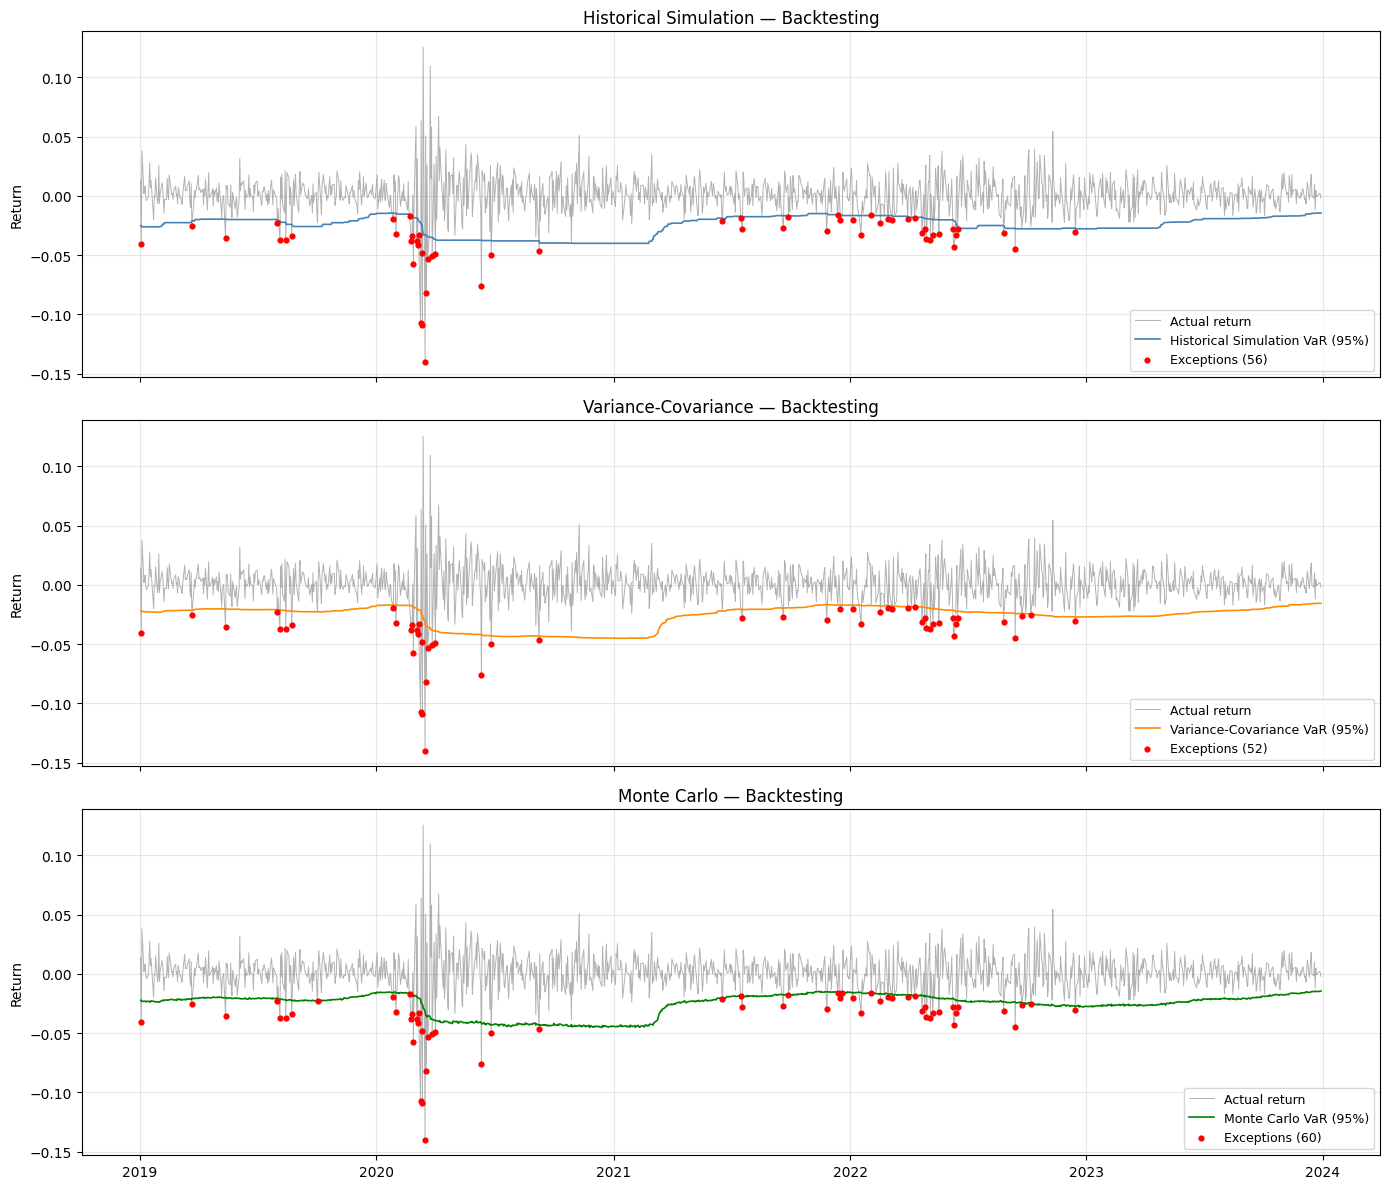


Plot saved as backtesting_results.png


In [14]:
# ── Cell 11: Combined results + backtesting plot ──────────────────

print("═" * 72)
print("FULL BACKTESTING SUMMARY")
print("═" * 72)
print(f"{'Metric':<32} {'Hist Sim':>12} {'Var-Cov':>12} {'Monte Carlo':>12}")
print("-" * 72)
print(f"{'Total days tested':<32} {T:>12} {T:>12} {T:>12}")
print(f"{'Expected exceptions (5%)':<32} {expected_exceptions:>12.1f} {expected_exceptions:>12.1f} {expected_exceptions:>12.1f}")
print(f"{'Actual exceptions':<32} {hs_count:>12} {vc_count:>12} {mc_count:>12}")
print(f"{'Exception rate':<32} {hs_count/T*100:>11.2f}% {vc_count/T*100:>11.2f}% {mc_count/T*100:>11.2f}%")
print(f"{'Kupiec test':<32} {hs_kup:>12} {vc_kup:>12} {mc_kup:>12}")
print(f"{'Christoffersen test':<32} {hs_chris:>12} {vc_chris:>12} {mc_chris:>12}")
print(f"{'Basel zone':<32} {hs_zone:>12} {vc_zone:>12} {mc_zone:>12}")
print("═" * 72)

# ── Backtesting plot ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

models     = [('Historical Simulation', hs, hs_exceptions, 'steelblue'),
              ('Variance-Covariance',   vc, vc_exceptions, 'darkorange'),
              ('Monte Carlo',           mc, mc_exceptions, 'green')]

for ax, (name, var_series, exceptions, color) in zip(axes, models):
    # Plot actual returns
    ax.plot(common_idx, actual,
            color='gray', linewidth=0.7, alpha=0.6, label='Actual return')

    # Plot VaR line
    ax.plot(common_idx, var_series,
            color=color, linewidth=1.2, label=f'{name} VaR (95%)')

    # Plot exception days as red dots
    breach_dates = common_idx[exceptions.values == 1]
    breach_vals  = actual[exceptions.values == 1]
    ax.scatter(breach_dates, breach_vals,
               color='red', s=12, zorder=5,
               label=f'Exceptions ({exceptions.sum()})')

    ax.set_ylabel('Return')
    ax.set_title(f'{name} — Backtesting')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backtesting_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as backtesting_results.png")